# Raw Intensity And Colormap Checks

Use this notebook to check whether diffraction-spot intensities are being displayed and normalized in a sensible way. The plots deliberately compare raw linear intensity, log intensity, robust display limits, and the same percentile normalization used in `train.py`.

Important: a colormap only changes what you see on screen. The training-relevant part is the numeric scaling. In this project, `train.py` normalizes each sample by the input image's 1st and 99.8th percentiles, then applies the same limits to the two target spot channels.

In [ ]:
from pathlib import Path
import json

import h5py
import hdf5plugin  # noqa: F401 - registers ESRF compression filters for h5py reads
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np


def find_project_dir():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "train.py").exists() and (candidate / "augment_data").exists():
            return candidate
    raise RuntimeError("Could not find project directory containing train.py and augment_data/.")


PROJECT_DIR = find_project_dir()
DATA_ESRF = PROJECT_DIR.parent / "data_esrf"
RAW_ROOTS = [DATA_ESRF]
CATALOG_FILE = DATA_ESRF / "confirmed_spots_merged.h5"
if not CATALOG_FILE.exists():
    CATALOG_FILE = DATA_ESRF / "confirmed_spots_all.h5"
AUGMENTED_FILE = DATA_ESRF / "augmented_spot_patches.h5"
RAW_KEY = "instrument/detector_0/data"

print(f"Project dir   : {PROJECT_DIR}")
print(f"Catalog       : {CATALOG_FILE}  exists={CATALOG_FILE.exists()}")
print(f"Augmented file: {AUGMENTED_FILE}  exists={AUGMENTED_FILE.exists()}")

Project dir   : /var/home/natalieboehm/Documents/Studium/Master/Masterarbeit/Code
Catalog       : /var/home/natalieboehm/Documents/Studium/Master/Masterarbeit/data_esrf/confirmed_spots_merged.h5  exists=True
Augmented file: /var/home/natalieboehm/Documents/Studium/Master/Masterarbeit/data_esrf/augmented_spot_patches.h5  exists=True


In [ ]:
def material_from_scan(scan):
    return str(scan).split("_")[0]


def dataset_exists(h5_file, key):
    try:
        with h5py.File(h5_file, "r") as f:
            return key in f and isinstance(f[key], h5py.Dataset)
    except OSError:
        return False


def first_3d_dataset(h5_file):
    found = []
    try:
        with h5py.File(h5_file, "r") as f:
            def visitor(name, obj):
                if isinstance(obj, h5py.Dataset) and obj.ndim >= 3:
                    found.append(name)
            f.visititems(visitor)
    except OSError as exc:
        print(f"Skipping unreadable HDF5 candidate {h5_file}: {exc}")
        return None
    return found[0] if found else None


def find_scan_dir(scan):
    for root in RAW_ROOTS:
        scan_dir = root / scan
        if scan_dir.exists():
            return scan_dir
    raise FileNotFoundError(f"Could not find scan directory for {scan!r} in {RAW_ROOTS}")


def find_raw_file(scan):
    scan_dir = find_scan_dir(scan)
    h5_files = sorted(
        p for p in scan_dir.glob("*.h5")
        if p.name != "segvol.h5" and "dark" not in p.name.lower() and "confirmed" not in p.name.lower()
    )
    if not h5_files:
        raise FileNotFoundError(f"No raw .h5 file found in {scan_dir}")
    for h5_file in h5_files:
        if dataset_exists(h5_file, RAW_KEY):
            return h5_file, RAW_KEY
    for h5_file in h5_files:
        key = first_3d_dataset(h5_file)
        if key is not None:
            print(f"Using fallback raw dataset {key!r} in {h5_file.name} for scan {scan}")
            return h5_file, key
    raise FileNotFoundError(f"No 3D raw dataset found in {scan_dir}")


RAW_CACHE = {}


def raw_source(scan):
    if scan not in RAW_CACHE:
        RAW_CACHE[scan] = find_raw_file(scan)
    return RAW_CACHE[scan]


def load_raw_frame(scan, frame):
    raw_file, raw_key = raw_source(scan)
    with h5py.File(raw_file, "r") as f:
        data = f[raw_key]
        frame = int(frame) % data.shape[0]
        return np.asarray(data[frame])


def collect_spots(catalog_file):
    spots = []
    with h5py.File(catalog_file, "r") as f:
        def visitor(name, obj):
            if not isinstance(obj, h5py.Group) or "mask" not in obj or "bbox" not in obj:
                return
            scan = obj.attrs.get("scan", name.split("/")[0])
            mask = np.asarray(obj["mask"][()], dtype=bool)
            if mask.sum() == 0:
                return
            spots.append({
                "name": name,
                "scan": str(scan),
                "dataset": str(scan),
                "material": material_from_scan(scan),
                "frame": int(obj.attrs.get("frame")),
                "blob_id": int(obj.attrs.get("blob_id", -1)),
                "bbox": np.asarray(obj["bbox"][()], dtype=np.int32),
                "mask": mask,
                "area_px": int(mask.sum()),
            })
        f.visititems(visitor)
    return spots


SPOTS = collect_spots(CATALOG_FILE)
BY_DATASET = {}
for spot in SPOTS:
    BY_DATASET.setdefault(spot["dataset"], []).append(spot)

print(f"Loaded {len(SPOTS)} confirmed spots")
for dataset, spots in sorted(BY_DATASET.items()):
    print(f"{dataset:<24} {len(spots):>4} spot(s), material={sorted({s['material'] for s in spots})}")

Loaded 172 confirmed spots
Al                         35 spot(s), material=['Al']
Al_big_grains              28 spot(s), material=['Al']
Al_small_grains            13 spot(s), material=['Al']
Cu                         10 spot(s), material=['Cu']
IN718_twins                32 spot(s), material=['IN718']
Iron                       32 spot(s), material=['Iron']
Iron_deformed               5 spot(s), material=['Iron']
Ti7Al                      17 spot(s), material=['Ti7Al']


In [ ]:
def bbox_crop_candidates(raw, bbox, mask_shape):
    a0, b0, a1, b1 = map(int, bbox)
    conventions = [
        ("row_col_exclusive", (a0, b0, a1, b1)),
        ("xy_exclusive", (b0, a0, b1, a1)),
        ("row_col_inclusive", (a0, b0, a1 + 1, b1 + 1)),
        ("xy_inclusive", (b0, a0, b1 + 1, a1 + 1)),
    ]
    seen = set()
    for name, (r0, c0, r1, c1) in conventions:
        key = (r0, c0, r1, c1)
        if key in seen:
            continue
        seen.add(key)
        if r0 < 0 or c0 < 0 or r1 > raw.shape[0] or c1 > raw.shape[1] or r1 <= r0 or c1 <= c0:
            continue
        crop = raw[r0:r1, c0:c1].astype(np.float32, copy=True)
        raw_bbox = [int(r0), int(c0), int(r1), int(c1)]
        if crop.shape == mask_shape:
            yield name, crop, raw_bbox
        if crop.T.shape == mask_shape:
            yield f"{name}_transposed", crop.T.copy(), raw_bbox


def tight_slices(mask, margin=0):
    rows, cols = np.where(mask)
    if rows.size == 0:
        raise ValueError("Cannot crop an empty mask")
    r0 = max(int(rows.min()) - margin, 0)
    c0 = max(int(cols.min()) - margin, 0)
    r1 = min(int(rows.max()) + margin + 1, mask.shape[0])
    c1 = min(int(cols.max()) + margin + 1, mask.shape[1])
    return slice(r0, r1), slice(c0, c1)


def extract_raw_crop_and_signal(spot, margin=8):
    raw = load_raw_frame(spot["scan"], spot["frame"]).astype(np.float32, copy=False)
    mask = spot["mask"].astype(bool, copy=False)
    candidates = list(bbox_crop_candidates(raw, spot["bbox"], mask.shape))
    if not candidates:
        raise ValueError(f"Could not align raw crop and mask for {spot['name']}")
    preferred = [candidate for candidate in candidates if "transposed" not in candidate[0]]
    bbox_convention, crop, raw_bbox = (preferred or candidates)[0]
    background_pixels = crop[~mask]
    local_background = float(np.median(background_pixels)) if background_pixels.size else float(np.percentile(crop, 10))
    signal = crop - local_background
    signal[~mask] = 0.0
    signal[signal < 0] = 0.0
    rr, cc = tight_slices(mask, margin=margin)
    return {
        "raw_crop": crop,
        "mask": mask,
        "signal_crop": signal,
        "raw_tight": crop[rr, cc],
        "mask_tight": mask[rr, cc],
        "signal_tight": signal[rr, cc],
        "local_background": local_background,
        "bbox_convention": bbox_convention,
        "raw_bbox": raw_bbox,
    }


def positive_values(array):
    values = np.asarray(array)[np.isfinite(array)]
    return values[values > 0]


def robust_limits(array, lower=1, upper=99.8, positive_only=True):
    values = np.asarray(array)[np.isfinite(array)]
    if positive_only:
        values = values[values > 0]
    if values.size == 0:
        return 0.0, 1.0
    vmin, vmax = np.percentile(values, [lower, upper])
    if vmax <= vmin:
        vmin, vmax = float(values.min()), float(values.max())
    if vmax <= vmin:
        vmax = vmin + 1.0
    return float(vmin), float(vmax)


def train_normalize_image_and_targets(image, targets):
    image = image.astype(np.float32, copy=False)
    targets = targets.astype(np.float32, copy=False)
    finite = np.isfinite(image)
    if not finite.any():
        return np.zeros_like(image), np.zeros_like(targets), (0.0, 1.0)
    values = image[finite]
    lo, hi = np.percentile(values, [1, 99.9])
    if hi <= lo:
        lo, hi = float(values.min()), float(values.max())
    if hi <= lo:
        return np.zeros_like(image), np.zeros_like(targets), (float(lo), float(hi))
    image_out = np.clip(image, lo, hi)
    image_out = (image_out - lo) / (hi - lo)
    image_out[~finite] = 0.0
    targets_out = np.clip(targets, lo, hi)
    targets_out = (targets_out - lo) / (hi - lo)
    targets_out[~np.isfinite(targets_out)] = 0.0
    return image_out.astype(np.float32), targets_out.astype(np.float32), (float(lo), float(hi))

Spot: Al/frame_1100_blob_0084  frame=1100  bbox=[1648, 119, 1791, 286]
Raw source: (PosixPath('/var/home/natalieboehm/Documents/Studium/Master/Masterarbeit/data_esrf/Al/_iris_iris_500_cont.h5'), 'instrument/detector_0/data')
bbox convention: row_col_exclusive  raw_bbox=[1648, 119, 1791, 286]
local background median: 129.000
raw inside mask min/median/max/sum: 141.000, 231.000, 301.000, 2.334e+06
raw outside median: 129.000
signal inside min/median/max/sum: 12.000, 102.000, 172.000, 9.855e+05


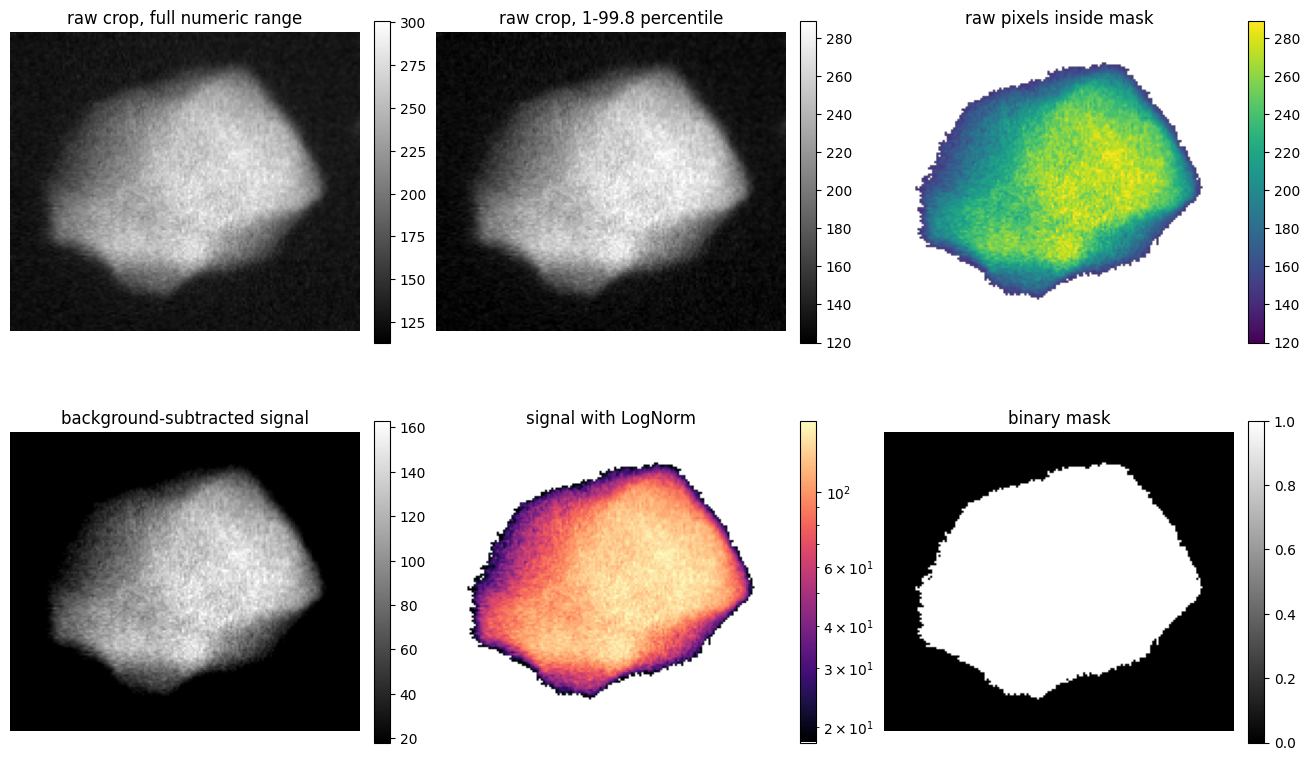

In [ ]:
# Pick one raw catalog spot and compare display choices.
# Change DATASET_NAME and SPOT_INDEX to browse other spots.
DATASET_NAME = None  # e.g. "Al", "Al_big_grains", "Iron"; None uses the first dataset
SPOT_INDEX = 0

dataset_name = DATASET_NAME or sorted(BY_DATASET)[0]
spot = BY_DATASET[dataset_name][SPOT_INDEX]
crop_info = extract_raw_crop_and_signal(spot, margin=8)
raw_crop = crop_info["raw_crop"]
mask = crop_info["mask"]
signal = crop_info["signal_crop"]

masked_raw = np.where(mask, raw_crop, np.nan)
raw_limits = robust_limits(raw_crop, positive_only=False)
signal_limits = robust_limits(signal)
log_values = positive_values(signal)
log_vmin = max(float(np.percentile(log_values, 1)), 1e-6) if log_values.size else 1e-6
log_vmax = float(np.percentile(log_values, 99.8)) if log_values.size else 1.0

fig, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
panels = [
    (raw_crop, "raw crop, full numeric range", "gray", None, None, None),
    (raw_crop, "raw crop, 1-99.8 percentile", "gray", raw_limits[0], raw_limits[1], None),
    (masked_raw, "raw pixels inside mask", "viridis", raw_limits[0], raw_limits[1], None),
    (signal, "background-subtracted signal", "gray", signal_limits[0], signal_limits[1], None),
    (signal, "signal with LogNorm", "magma", None, None, LogNorm(vmin=log_vmin, vmax=max(log_vmax, log_vmin * 1.01))),
    (mask, "binary mask", "gray", 0, 1, None),
]
for ax, (data, title, cmap, vmin, vmax, norm) in zip(axes.flat, panels):
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, norm=norm)
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

inside = raw_crop[mask]
outside = raw_crop[~mask]
signal_inside = signal[mask]
print(f"Spot: {spot['name']}  frame={spot['frame']}  bbox={spot['bbox'].tolist()}")
print(f"Raw source: {raw_source(spot['scan'])}")
print(f"bbox convention: {crop_info['bbox_convention']}  raw_bbox={crop_info['raw_bbox']}")
print(f"local background median: {crop_info['local_background']:.3f}")
print(f"raw inside mask min/median/max/sum: {inside.min():.3f}, {np.median(inside):.3f}, {inside.max():.3f}, {inside.sum():.3e}")
print(f"raw outside median: {np.median(outside):.3f}" if outside.size else "raw outside median: <no outside pixels>")
print(f"signal inside min/median/max/sum: {signal_inside.min():.3f}, {np.median(signal_inside):.3f}, {signal_inside.max():.3f}, {signal_inside.sum():.3e}")

Measured 145 raw spot crops
Al                       n= 25  sum median=6.075e+05, range=(1.782e+05, 1.362e+07)  peak median=301.000, range=(84.000, 2485.000)
Al_big_grains            n= 25  sum median=4.496e+06, range=(1.470e+05, 6.247e+07)  peak median=2842.000, range=(731.000, 11505.000)
Al_small_grains          n= 13  sum median=4.709e+05, range=(1.297e+05, 1.167e+06)  peak median=1511.000, range=(195.000, 4438.000)
Cu                       n= 10  sum median=2.434e+05, range=(8.148e+04, 5.816e+05)  peak median=1058.500, range=(464.000, 1536.000)
IN718_twins              n= 25  sum median=4.941e+05, range=(1.298e+05, 7.371e+06)  peak median=375.000, range=(96.000, 1711.000)
Iron                     n= 25  sum median=1.053e+06, range=(1.357e+05, 3.602e+06)  peak median=1817.000, range=(976.000, 4115.000)
Iron_deformed            n=  5  sum median=2.550e+05, range=(1.720e+05, 4.354e+05)  peak median=675.000, range=(355.000, 1254.000)
Ti7Al                    n= 17  sum median=1.353e+06

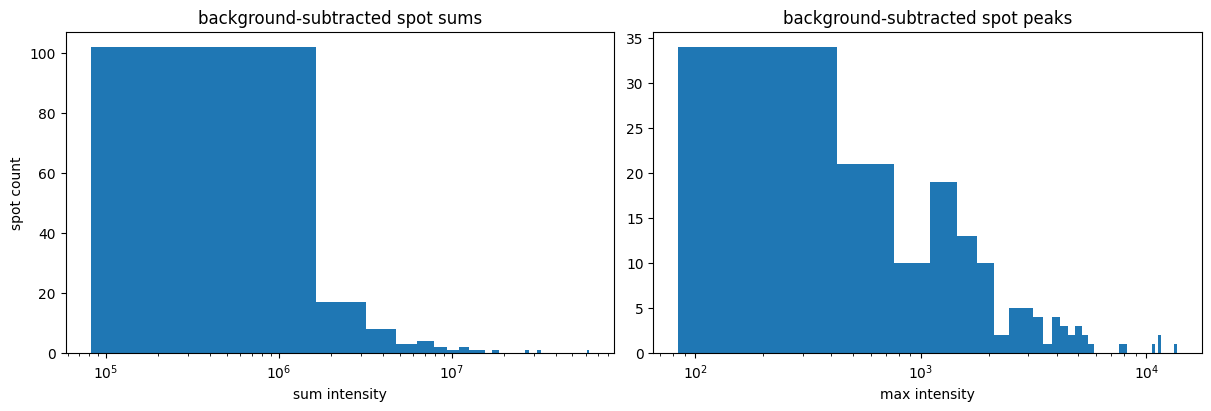

In [5]:
# Summarize raw spot intensity distributions across the catalog.
# Increase MAX_SPOTS_PER_DATASET if you want a more exhaustive check.
MAX_SPOTS_PER_DATASET = 25

records = []
for dataset, spots in sorted(BY_DATASET.items()):
    for spot in spots[:MAX_SPOTS_PER_DATASET]:
        try:
            info = extract_raw_crop_and_signal(spot, margin=8)
        except Exception as exc:
            print(f"Skipping {spot['name']}: {exc}")
            continue
        signal = info["signal_crop"]
        mask = info["mask"]
        vals = signal[mask]
        records.append({
            "dataset": dataset,
            "spot": spot["name"],
            "area_px": int(mask.sum()),
            "sum": float(vals.sum()),
            "max": float(vals.max()) if vals.size else 0.0,
            "p99_8": float(np.percentile(vals[vals > 0], 99.8)) if np.any(vals > 0) else 0.0,
            "background": float(info["local_background"]),
        })

print(f"Measured {len(records)} raw spot crops")
for dataset in sorted({r['dataset'] for r in records}):
    subset = [r for r in records if r['dataset'] == dataset]
    sums = np.array([r['sum'] for r in subset])
    peaks = np.array([r['max'] for r in subset])
    print(
        f"{dataset:<24} n={len(subset):>3}  "
        f"sum median={np.median(sums):.3e}, range=({sums.min():.3e}, {sums.max():.3e})  "
        f"peak median={np.median(peaks):.3f}, range=({peaks.min():.3f}, {peaks.max():.3f})"
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].hist([r['sum'] for r in records if r['sum'] > 0], bins=40)
axes[0].set_xscale("log")
axes[0].set_title("background-subtracted spot sums")
axes[0].set_xlabel("sum intensity")
axes[0].set_ylabel("spot count")
axes[1].hist([r['max'] for r in records if r['max'] > 0], bins=40)
axes[1].set_xscale("log")
axes[1].set_title("background-subtracted spot peaks")
axes[1].set_xlabel("max intensity")
plt.show()

Archive samples: 4468; showing 5 from start=0


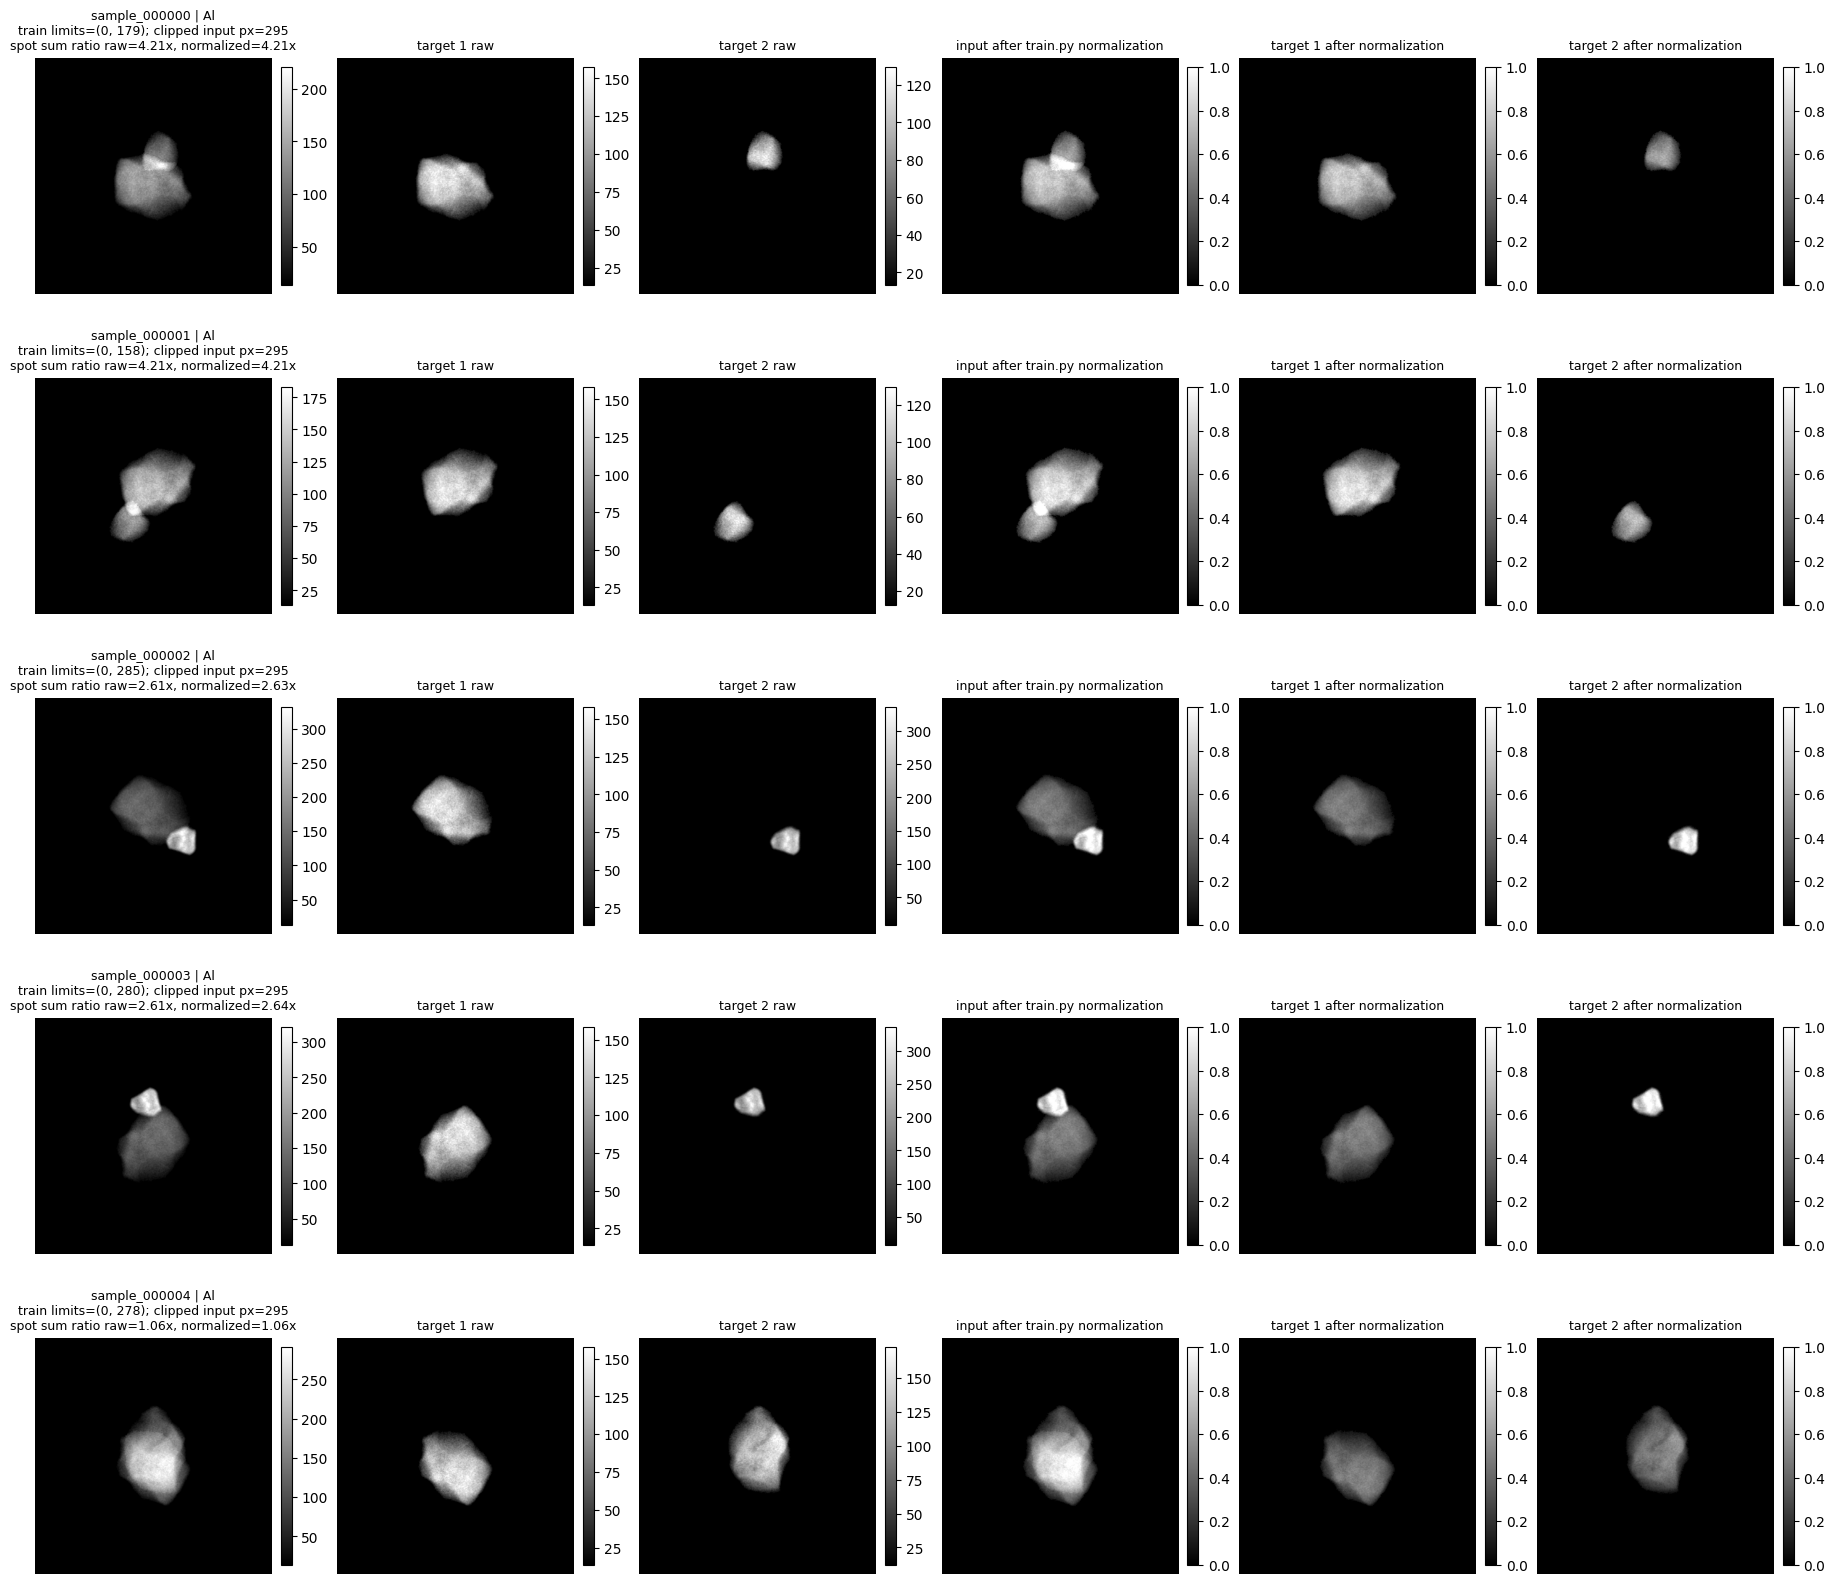

In [6]:
# Inspect saved augmented samples and compare raw saved intensities to train.py normalization.
# This is the best check for whether relative spot intensities survive the current training preprocessing.
AUG_START = 0
AUG_COUNT = 5
AUG_DATASET = None  # e.g. "Al", "Iron"; None means all saved samples

if not AUGMENTED_FILE.exists():
    raise FileNotFoundError(AUGMENTED_FILE)

def sample_names_from_archive(path, dataset=None):
    with h5py.File(path, "r") as f:
        names = sorted(k for k, v in f.items() if isinstance(v, h5py.Group) and "image" in v and "spot_images" in v)
        if dataset is not None:
            names = [name for name in names if f[name].attrs.get("dataset") == dataset]
        return names

sample_names = sample_names_from_archive(AUGMENTED_FILE, AUG_DATASET)
selected = sample_names[AUG_START:AUG_START + AUG_COUNT]
print(f"Archive samples: {len(sample_names)}; showing {len(selected)} from start={AUG_START}")

fig, axes = plt.subplots(len(selected), 6, figsize=(18, 3.2 * max(1, len(selected))), squeeze=False, constrained_layout=True)
with h5py.File(AUGMENTED_FILE, "r") as f:
    for row, name in enumerate(selected):
        group = f[name]
        image = group["image"][()]
        targets = group["spot_images"][()]
        image_norm, targets_norm, limits = train_normalize_image_and_targets(image, targets)
        sums_raw = targets.reshape(2, -1).sum(axis=1)
        sums_norm = targets_norm.reshape(2, -1).sum(axis=1)
        ratio_raw = max(sums_raw) / max(min(sums_raw), 1e-12)
        ratio_norm = max(sums_norm) / max(min(sums_norm), 1e-12)
        clipped_px = int(np.count_nonzero(image > limits[1]))
        title = (
            f"{name} | {group.attrs.get('dataset', '<missing>')}\n"
            f"train limits=({limits[0]:.3g}, {limits[1]:.3g}); clipped input px={clipped_px}\n"
            f"spot sum ratio raw={ratio_raw:.2f}x, normalized={ratio_norm:.2f}x"
        )
        panels = [
            (image, title, "gray", *robust_limits(image), None),
            (targets[0], "target 1 raw", "gray", *robust_limits(targets[0]), None),
            (targets[1], "target 2 raw", "gray", *robust_limits(targets[1]), None),
            (image_norm, "input after train.py normalization", "gray", 0.0, 1.0, None),
            (targets_norm[0], "target 1 after normalization", "gray", 0.0, 1.0, None),
            (targets_norm[1], "target 2 after normalization", "gray", 0.0, 1.0, None),
        ]
        for ax, (data, panel_title, cmap, vmin, vmax, norm) in zip(axes[row], panels):
            im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, norm=norm)
            ax.set_title(panel_title, fontsize=9)
            ax.axis("off")
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()

Checked 500 saved samples
raw spot ratio median/range: 2.700 / (1.012, 75.477)
normalized spot ratio median/range: 2.706 / (1.004, 75.457)
normalized/raw ratio-change median/range: 1.000 / (0.944, 1.057)
samples with clipped target pixels: 282 / 500

Largest raw-vs-normalized ratio changes:
sample_000082 Al: raw=1.526x, norm=1.441x, limits=(0, 855), clipped_target_px=147
sample_000326 Al: raw=1.164x, norm=1.230x, limits=(0, 859), clipped_target_px=145
sample_000327 Al: raw=1.163x, norm=1.228x, limits=(0, 862), clipped_target_px=145
sample_000437 Al: raw=1.356x, norm=1.287x, limits=(0, 868), clipped_target_px=144
sample_000209 Al: raw=2.936x, norm=3.085x, limits=(0, 874), clipped_target_px=141
sample_000268 Al: raw=1.976x, norm=1.885x, limits=(0, 879), clipped_target_px=135
sample_000269 Al: raw=1.977x, norm=1.892x, limits=(0, 886), clipped_target_px=131
sample_000017 Al: raw=2.759x, norm=2.874x, limits=(0, 896), clipped_target_px=125
sample_000147 Al: raw=1.059x, norm=1.102x, limits=(0

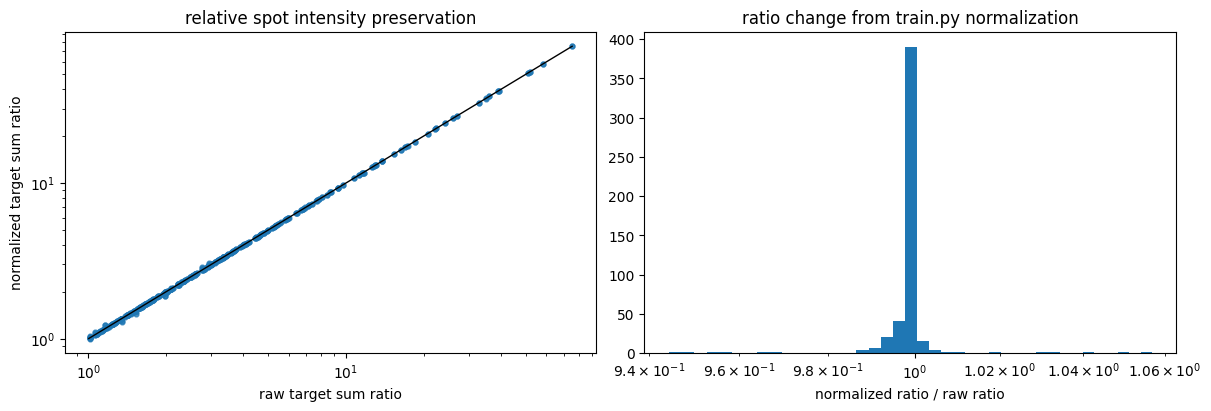

In [9]:
# Numeric archive-wide check: how much does train.py normalization alter target intensity ratios?
# Large changes here mean clipping/normalization may be hiding physically meaningful intensity differences.
MAX_ARCHIVE_SAMPLES = 500

rows = []
with h5py.File(AUGMENTED_FILE, "r") as f:
    names = sorted(k for k, v in f.items() if isinstance(v, h5py.Group) and "image" in v and "spot_images" in v)
    for name in names[:MAX_ARCHIVE_SAMPLES]:
        group = f[name]
        image = group["image"][()]
        targets = group["spot_images"][()]
        image_norm, targets_norm, limits = train_normalize_image_and_targets(image, targets)
        raw_sums = targets.reshape(2, -1).sum(axis=1)
        norm_sums = targets_norm.reshape(2, -1).sum(axis=1)
        rows.append({
            "name": name,
            "dataset": group.attrs.get("dataset", "<missing>"),
            "raw_ratio": float(max(raw_sums) / max(min(raw_sums), 1e-12)),
            "norm_ratio": float(max(norm_sums) / max(min(norm_sums), 1e-12)),
            "lo": limits[0],
            "hi": limits[1],
            "clipped_input_px": int(np.count_nonzero(image > limits[1])),
            "clipped_target_px": int(np.count_nonzero(targets > limits[1])),
            "image_sum_raw": float(image.sum()),
            "image_sum_norm": float(image_norm.sum()),
        })

raw_ratios = np.array([r["raw_ratio"] for r in rows])
norm_ratios = np.array([r["norm_ratio"] for r in rows])
ratio_change = norm_ratios / np.maximum(raw_ratios, 1e-12)
clipped_targets = np.array([r["clipped_target_px"] for r in rows])
print(f"Checked {len(rows)} saved samples")
print(f"raw spot ratio median/range: {np.median(raw_ratios):.3f} / ({raw_ratios.min():.3f}, {raw_ratios.max():.3f})")
print(f"normalized spot ratio median/range: {np.median(norm_ratios):.3f} / ({norm_ratios.min():.3f}, {norm_ratios.max():.3f})")
print(f"normalized/raw ratio-change median/range: {np.median(ratio_change):.3f} / ({ratio_change.min():.3f}, {ratio_change.max():.3f})")
print(f"samples with clipped target pixels: {np.count_nonzero(clipped_targets)} / {len(rows)}")

worst = sorted(rows, key=lambda r: abs(np.log((r['norm_ratio'] + 1e-12) / (r['raw_ratio'] + 1e-12))), reverse=True)[:10]
print("\nLargest raw-vs-normalized ratio changes:")
for r in worst:
    print(
        f"{r['name']} {r['dataset']}: raw={r['raw_ratio']:.3f}x, norm={r['norm_ratio']:.3f}x, "
        f"limits=({r['lo']:.3g}, {r['hi']:.3g}), clipped_target_px={r['clipped_target_px']}"
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].scatter(raw_ratios, norm_ratios, s=12, alpha=0.7)
lims = [min(raw_ratios.min(), norm_ratios.min()), max(raw_ratios.max(), norm_ratios.max())]
axes[0].plot(lims, lims, color="black", linewidth=1)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("raw target sum ratio")
axes[0].set_ylabel("normalized target sum ratio")
axes[0].set_title("relative spot intensity preservation")
axes[1].hist(ratio_change[np.isfinite(ratio_change)], bins=40)
axes[1].set_xscale("log")
axes[1].set_xlabel("normalized ratio / raw ratio")
axes[1].set_title("ratio change from train.py normalization")
plt.show()